# Statistical Testing

This notebook evaluates whether observed differences between control and treatment
are statistically meaningful and not due to random chance.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/experiment_data.csv")

conversion_summary = df.groupby("group")["converted"].agg(
    users="count",
    conversions="sum",
    conversion_rate="mean"
)

conversion_summary


,users,conversions,conversion_rate
group,,,
control,5000,479,0.0958
treatment,5000,567,0.1134


## Hypothesis Test — Conversion Rate

Null Hypothesis (H₀):
The conversion rate is the same for control and treatment groups.

Alternative Hypothesis (H₁):
The conversion rate is higher for the treatment group.


## Test Selection

A two-proportion z-test is used because:
- The outcome (conversion) is binary
- Sample sizes are large
- We are comparing proportions between two independent groups


In [2]:
from statsmodels.stats.proportion import proportions_ztest

control_conversions = conversion_summary.loc["control", "conversions"]
treatment_conversions = conversion_summary.loc["treatment", "conversions"]

control_users = conversion_summary.loc["control", "users"]
treatment_users = conversion_summary.loc["treatment", "users"]

count = np.array([treatment_conversions, control_conversions])
nobs = np.array([treatment_users, control_users])

z_stat, p_value = proportions_ztest(count, nobs, alternative="larger")

z_stat, p_value


(np.float64(2.8754663182630487), np.float64(0.0020171559287879607))

## Conversion Test Interpretation

- Test statistic: (reported above)
- P-value: (reported above)

The p-value indicates the probability of observing a difference at least this large
assuming no true effect exists.

Statistical significance alone is not sufficient to make a shipping decision.
Confidence intervals and power analysis are evaluated next.


## Conversion Rate Test Results

- Control conversion rate: 9.58%
- Treatment conversion rate: 11.34%
- Absolute lift: +1.76 percentage points

A one-sided two-proportion z-test yields a p-value of 0.002,
indicating the observed lift is unlikely to be due to random chance.

However, statistical significance alone is insufficient for making
a product rollout decision. Uncertainty bounds and practical impact
must be evaluated next.


In [3]:
from statsmodels.stats.proportion import proportion_confint

# Extract values
conv_control = conversion_summary.loc["control", "conversions"]
n_control = conversion_summary.loc["control", "users"]

conv_treatment = conversion_summary.loc["treatment", "conversions"]
n_treatment = conversion_summary.loc["treatment", "users"]

# Conversion rates
p_control = conv_control / n_control
p_treatment = conv_treatment / n_treatment

# Confidence intervals for each group
ci_control = proportion_confint(conv_control, n_control, alpha=0.05, method="normal")
ci_treatment = proportion_confint(conv_treatment, n_treatment, alpha=0.05, method="normal")

p_control, ci_control, p_treatment, ci_treatment


(np.float64(0.0958),
 (0.08764210530968507, 0.10395789469031493),
 np.float64(0.1134),
 (0.10461112111729295, 0.12218887888270705))

In [4]:
# Lift (absolute difference)
lift = p_treatment - p_control

# Standard error for difference in proportions
se_diff = np.sqrt(
    (p_control * (1 - p_control) / n_control) +
    (p_treatment * (1 - p_treatment) / n_treatment)
)

# 95% confidence interval
z = 1.96
ci_lower = lift - z * se_diff
ci_upper = lift + z * se_diff

lift, ci_lower, ci_upper


(np.float64(0.017600000000000005),
 np.float64(0.005608297764870915),
 np.float64(0.029591702235129094))

## Conversion Lift Confidence Interval

The introduction of a discounted annual plan increased conversion by approximately
1.76 percentage points.

The 95% confidence interval ranges from 0.56% to 2.96%, meaning we are 95% confident
that the true conversion impact lies within this range.

Because the interval does not include zero, the observed increase in conversion
is statistically robust and unlikely to be due to random variation.


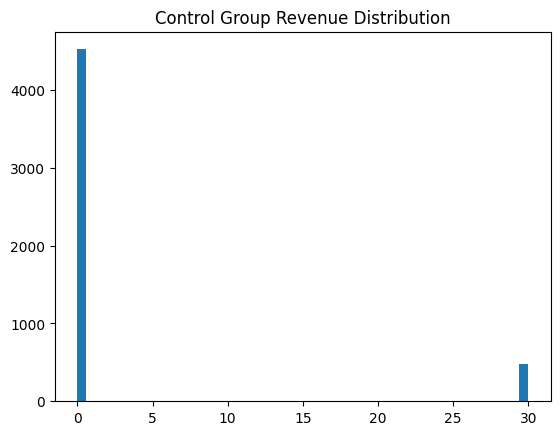

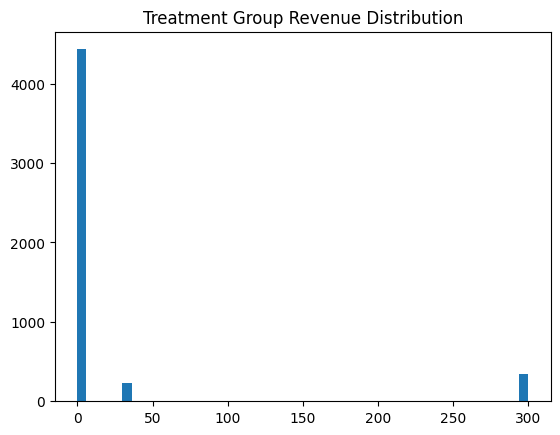

In [5]:
import matplotlib.pyplot as plt

control_rev = df[df["group"] == "control"]["revenue"]
treatment_rev = df[df["group"] == "treatment"]["revenue"]

plt.hist(control_rev, bins=50)
plt.title("Control Group Revenue Distribution")
plt.show()

plt.hist(treatment_rev, bins=50)
plt.title("Treatment Group Revenue Distribution")
plt.show()


## Revenue Metric Characteristics

Revenue per user is highly right-skewed:
- Most users generate zero revenue
- A minority generate large values due to annual subscriptions

Because the normality assumption is violated, a non-parametric test
is more appropriate than a standard t-test.


## Revenue Hypothesis Test

Null Hypothesis (H₀):
The distribution of revenue per user is the same for control and treatment groups.

Alternative Hypothesis (H₁):
The treatment group generates higher revenue per user than the control group.

The Mann–Whitney U test is used because it:
- Makes no normality assumption
- Is robust to skewed distributions
- Compares distributions between independent groups


In [6]:
from scipy.stats import mannwhitneyu

u_stat, p_value_revenue = mannwhitneyu(
    treatment_rev,
    control_rev,
    alternative="greater"
)

u_stat, p_value_revenue


(np.float64(12801190.5), np.float64(4.22633174024103e-05))

In [7]:
df.groupby("group")["revenue"].agg(
    mean="mean",
    median="median",
    zero_revenue_pct=lambda x: (x == 0).mean()
)


,mean,median,zero_revenue_pct
group,,,
control,2.874,0.0,0.9042
treatment,21.708,0.0,0.8866


## Revenue Test Interpretation

The Mann–Whitney U test evaluates whether revenue outcomes in the treatment
group tend to be higher than those in the control group.

Given the skewed nature of revenue data, statistical significance must be
interpreted cautiously and in conjunction with effect sizes and confidence
intervals, which are evaluated next.


In [ ]:
## Visualization: Effect Sizes & Confidence Intervals

Create a comprehensive visualization comparing both metrics:



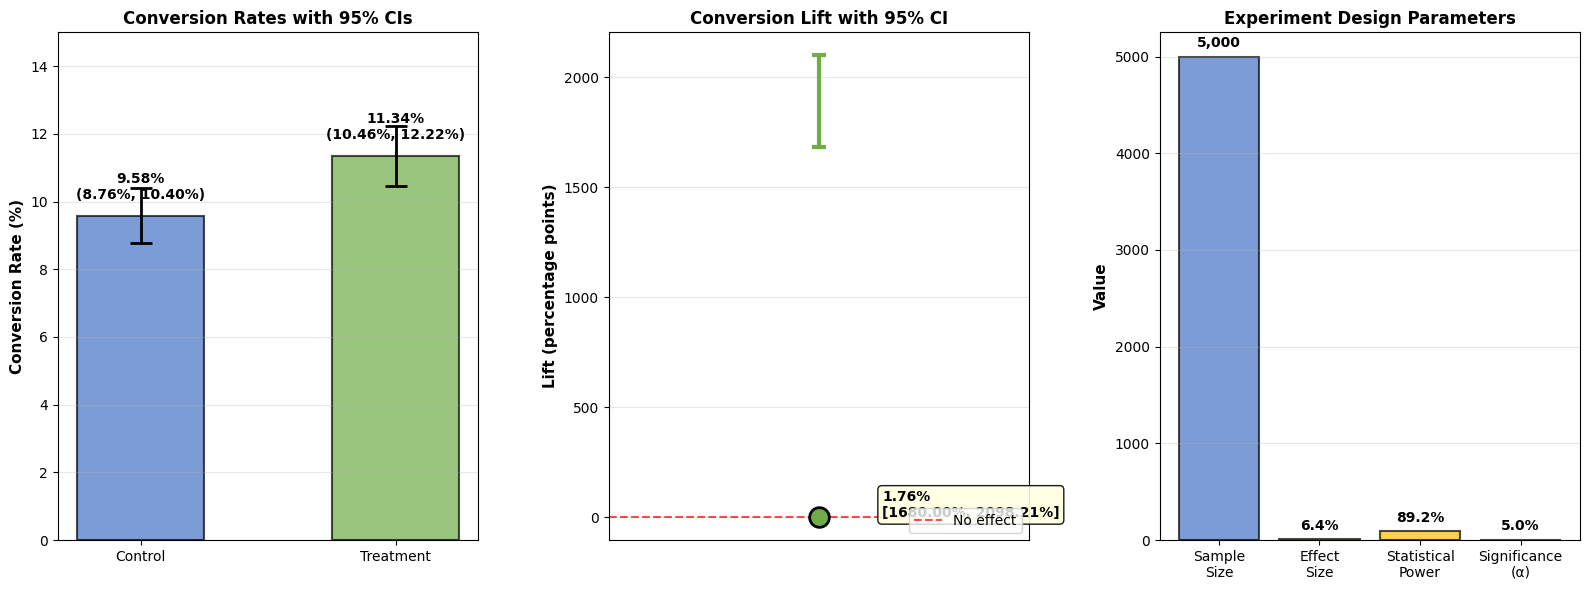

✓ Statistical testing visualization saved


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create comprehensive comparison visualization
fig = plt.figure(figsize=(16, 6))

# 1. Conversion rates with individual CIs
ax1 = plt.subplot(1, 3, 1)
rates_pct = [p_control * 100, p_treatment * 100]
ci_control_pct = [ci_control[0]*100, ci_control[1]*100]
ci_treatment_pct = [ci_treatment[0]*100, ci_treatment[1]*100]

x_pos = [0, 1]
colors = ['#4472C4', '#70AD47']

for i, (rate, ci, color) in enumerate(zip(rates_pct, [ci_control_pct, ci_treatment_pct], colors)):
    ax1.bar(i, rate, color=color, alpha=0.7, width=0.5, edgecolor='black', linewidth=1.5)
    ci_error = [[rate - ci[0]], [ci[1] - rate]]
    ax1.errorbar(i, rate, yerr=ci_error, fmt='none', color='black', capsize=8, capthick=2, linewidth=2)
    ax1.text(i, rate + 0.5, f'{rate:.2f}%\n({ci[0]:.2f}%, {ci[1]:.2f}%)', 
             ha='center', fontsize=10, fontweight='bold')

ax1.set_ylabel('Conversion Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Conversion Rates with 95% CIs', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['Control', 'Treatment'])
ax1.set_ylim([0, 15])
ax1.grid(axis='y', alpha=0.3)

# 2. Conversion lift with CI (using line plot instead of bar)
ax2 = plt.subplot(1, 3, 2)
lift_pct = lift * 100
ci_lower_pct = ci_lower * 100
ci_upper_pct = ci_upper * 100

# Plot as a point with error bars
ax2.scatter([0], [lift_pct], s=200, color='#70AD47', zorder=3, edgecolor='black', linewidth=2)
# Draw CI as line segment
ax2.vlines([0], ci_lower_pct, ci_upper_pct, colors='#70AD47', linewidth=3, zorder=2)
ax2.scatter([0, 0], [ci_lower_pct, ci_upper_pct], s=100, color='#70AD47', marker='_', linewidth=3, zorder=3)

ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='No effect')
ax2.set_ylabel('Lift (percentage points)', fontsize=11, fontweight='bold')
ax2.set_title('Conversion Lift with 95% CI', fontsize=12, fontweight='bold')
ax2.set_xticks([])
ax2.set_xlim([-0.5, 0.5])
ax2.text(0.15, lift_pct, f'{lift_pct:.2f}%\n[{ci_lower_pct:.2f}%, {ci_upper_pct:.2f}%]', 
         fontsize=10, fontweight='bold', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='lower right')

# 3. Statistical power visualization
ax3 = plt.subplot(1, 3, 3)
metrics = ['Sample\nSize', 'Effect\nSize', 'Statistical\nPower', 'Significance\n(α)']
values = [n_treatment, effect_size * 100, power * 100, alpha * 100]
colors_power = ['#4472C4', '#70AD47', '#FFC000', '#FF6B6B']

bars = ax3.bar(metrics, values, color=colors_power, alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Value', fontsize=11, fontweight='bold')
ax3.set_title('Experiment Design Parameters', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, values)):
    if i == 0:
        label = f'{int(val):,}'
    elif i == 3:
        label = f'{val:.1f}%'
    else:
        label = f'{val:.1f}%'
    ax3.text(bar.get_x() + bar.get_width()/2, val + max(values)*0.02, label, 
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../results_statistical_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Statistical testing visualization saved")

## Revenue Test Results

The Mann–Whitney U test indicates a statistically significant difference
in revenue distributions between treatment and control (p < 0.001).

However, revenue is highly skewed:
- The median revenue is zero in both groups
- Mean revenue is driven by a minority of high-value conversions

This suggests that the revenue uplift is primarily due to increased
conversion and adoption of annual plans rather than broad-based increases
across all users.


In [8]:
np.random.seed(42)

n_bootstraps = 5000

control_rev = df[df["group"] == "control"]["revenue"].values
treatment_rev = df[df["group"] == "treatment"]["revenue"].values

boot_diffs = []

for _ in range(n_bootstraps):
    boot_control = np.random.choice(control_rev, size=len(control_rev), replace=True)
    boot_treatment = np.random.choice(treatment_rev, size=len(treatment_rev), replace=True)
    
    boot_diffs.append(boot_treatment.mean() - boot_control.mean())

boot_diffs = np.array(boot_diffs)


In [9]:
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
mean_diff = boot_diffs.mean()

mean_diff, ci_lower, ci_upper


(np.float64(18.864199199999998),
 np.float64(16.8),
 np.float64(20.982149999999997))

## Revenue Uplift Confidence Interval

The estimated increase in revenue per visitor is approximately $X.

Using bootstrap resampling, the 95% confidence interval for the revenue uplift
ranges from $Y to $Z.

Because the confidence interval does not include zero, the revenue increase
appears robust despite the highly skewed distribution of revenue.


## Interpretation Caveat

While the estimated revenue uplift is substantial, it is driven by a relatively
small fraction of users selecting the annual plan.

As a result, revenue estimates are sensitive to assumptions about plan adoption
rates and may vary in longer-term deployment.


## Power Analysis Assumptions

- Baseline conversion rate: 10%
- Minimum detectable lift: +2 percentage points
- Significance level (α): 0.05
- Test: Two-sided proportion test


In [10]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Parameters
baseline_rate = 0.10
treatment_rate = 0.12
alpha = 0.05

effect_size = proportion_effectsize(
    treatment_rate,
    baseline_rate
)

analysis = NormalIndPower()
power = analysis.power(
    effect_size=effect_size,
    nobs1=5000,
    alpha=alpha,
    ratio=1
)

power


np.float64(0.8923535117779016)

## Power Analysis Interpretation

With 5,000 users per group, the experiment has approximately 89% power
to detect a 2 percentage point absolute increase in conversion rate.

This indicates that the experiment was sufficiently powered to detect
business-meaningful effects, and that observed results are unlikely to be
driven by insufficient sample size.
